In [28]:
import pandas as pd
import numpy as np

# --- 1. CHARGEMENT DES DONNÉES ---
try:
    df_clients = pd.read_csv("C:/content/sample_data/clients.csv")
    df_contracts = pd.read_csv("C:/content/sample_data/contracts.csv")
    df_interactions = pd.read_csv("C:/content/sample_data/interactions.csv")
    df_usage = pd.read_csv("C:/content/sample_data/usage.csv")
    
    print(" Chargement des 4 fichiers réussi.")

except FileNotFoundError as e:
    print(f" Erreur: Un des fichiers CSV n'a pas été trouvé. Veuillez vérifier les noms et le chemin. Détail: {e}")
    # Arrêter l'exécution si les fichiers ne sont pas là
    exit()

# --- 2. FUSION DES DATAFRAMES ---
# La clé de jointure commune est 'customerID'
# Nous utilisons une jointure 'inner' pour ne garder que les clients présents dans les 4 tables
# Si l'on souhaite garder tous les clients de la table clients.csv, utiliser 'left' (recommandé pour le churn)
df_final = df_clients.merge(df_contracts, on='customerID', how='left')
df_final = df_final.merge(df_usage, on='customerID', how='left')
df_final = df_final.merge(df_interactions, on='customerID', how='left')

print("\n Fusion des DataFrames terminée.")
print(f"Le jeu de données consolidé contient {df_final.shape[0]} lignes (clients) et {df_final.shape[1]} colonnes (caractéristiques).")

# Affichage des 5 premières lignes
print("\n--- Aperçu du DataFrame Final (df_final) ---")
print(df_final.head())

 Chargement des 4 fichiers réussi.

 Fusion des DataFrames terminée.
Le jeu de données consolidé contient 5568 lignes (clients) et 22 colonnes (caractéristiques).

--- Aperçu du DataFrame Final (df_final) ---
  customerID  gender  SeniorCitizen Partner Dependents  tenure Region   Age  \
0      C0001    Male              1     Yes        Yes       9  North  41.0   
1      C0002  Female              0      No         No      19   West  64.0   
2      C0003    Male              0     Yes         No      12   West  23.0   
3      C0004    Male              0     Yes         No      27  North  44.0   
4      C0005    Male              0      No         No      58  North  27.0   

  Churn    ContractType  ...     PaymentMethod  InternetService  \
0   Yes  Month-to-month  ...     Bank transfer      Fiber optic   
1    No  Month-to-month  ...  Electronic check              DSL   
2    No        One year  ...  Electronic check              DSL   
3    No  Month-to-month  ...  Electronic check  

In [29]:
df_final.isnull().sum()


customerID              0
gender                  0
SeniorCitizen           0
Partner               303
Dependents            433
tenure                  0
Region                  0
Age                   362
Churn                   0
ContractType          276
MonthlyCharges        276
TotalCharges          780
PaymentMethod         276
InternetService      1336
AvgDataUsage_GB       899
NumCalls              417
TVPackage             417
TechSupport           778
NbContacts            974
LastContactDays       627
SatisfactionScore    1093
FeedbackText          627
dtype: int64

In [30]:
df_final.describe()

,SeniorCitizen,tenure,Age,MonthlyCharges,TotalCharges,AvgDataUsage_GB,NumCalls,NbContacts,LastContactDays,SatisfactionScore
count,5568.000000,5568.000000,5206.000000,5292.000000,4788.000000,4669.000000,5151.000000,4594.000000,4941.000000,4475.000000
mean,0.178161,36.078484,54.150788,74.711693,2615.623342,52.137803,40.007765,2.223988,88.860150,3.023017
std,0.382683,20.757795,21.332628,31.465976,2122.687512,95.514666,6.299294,1.498277,51.967209,1.267932
min,0.000000,1.000000,18.000000,20.010000,3.680000,0.200000,20.000000,0.000000,0.000000,1.000000
25%,0.000000,18.000000,35.000000,48.297500,958.835000,19.100000,36.000000,1.000000,43.000000,2.000000
50%,0.000000,36.000000,54.000000,73.880000,2080.040000,34.400000,40.000000,2.000000,88.000000,3.000000
75%,0.000000,54.000000,73.000000,101.827500,3810.010000,54.400000,44.000000,3.000000,133.000000,4.000000
max,1.000000,72.000000,90.000000,129.990000,11276.170000,971.900000,63.000000,9.000000,180.000000,5.000000


In [31]:
df_final.columns[df_final.isnull().any()]

Index(['Partner', 'Dependents', 'Age', 'ContractType', 'MonthlyCharges',
       'TotalCharges', 'PaymentMethod', 'InternetService', 'AvgDataUsage_GB',
       'NumCalls', 'TVPackage', 'TechSupport', 'NbContacts', 'LastContactDays',
       'SatisfactionScore', 'FeedbackText'],
      dtype='object')

In [32]:
df_final.dtypes

customerID            object
gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
Region                object
Age                  float64
Churn                 object
ContractType          object
MonthlyCharges       float64
TotalCharges         float64
PaymentMethod         object
InternetService       object
AvgDataUsage_GB      float64
NumCalls             float64
TVPackage             object
TechSupport           object
NbContacts           float64
LastContactDays      float64
SatisfactionScore    float64
FeedbackText          object
dtype: object

In [33]:
df_final.info(memory_usage=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5568 entries, 0 to 5567
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerID         5568 non-null   object 
 1   gender             5568 non-null   object 
 2   SeniorCitizen      5568 non-null   int64  
 3   Partner            5265 non-null   object 
 4   Dependents         5135 non-null   object 
 5   tenure             5568 non-null   int64  
 6   Region             5568 non-null   object 
 7   Age                5206 non-null   float64
 8   Churn              5568 non-null   object 
 9   ContractType       5292 non-null   object 
 10  MonthlyCharges     5292 non-null   float64
 11  TotalCharges       4788 non-null   float64
 12  PaymentMethod      5292 non-null   object 
 13  InternetService    4232 non-null   object 
 14  AvgDataUsage_GB    4669 non-null   float64
 15  NumCalls           5151 non-null   float64
 16  TVPackage          5151 

In [34]:
df_final.describe().T.style.background_gradient().format("{:.3f}")

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,5568.000,0.178,0.383,0.000,0.000,0.000,0.000,1.000
tenure,5568.000,36.078,20.758,1.000,18.000,36.000,54.000,72.000
Age,5206.000,54.151,21.333,18.000,35.000,54.000,73.000,90.000
MonthlyCharges,5292.000,74.712,31.466,20.010,48.297,73.880,101.828,129.990
TotalCharges,4788.000,2615.623,2122.688,3.680,958.835,2080.040,3810.010,11276.170
AvgDataUsage_GB,4669.000,52.138,95.515,0.200,19.100,34.400,54.400,971.900
NumCalls,5151.000,40.008,6.299,20.000,36.000,40.000,44.000,63.000
NbContacts,4594.000,2.224,1.498,0.000,1.000,2.000,3.000,9.000
LastContactDays,4941.000,88.860,51.967,0.000,43.000,88.000,133.000,180.000
SatisfactionScore,4475.000,3.023,1.268,1.000,2.000,3.000,4.000,5.000


## Correction du Type de Données et Nettoyage


In [35]:
# --- 3. CONVERSION DE TYPE ET NETTOYAGE ---

# Convertir TotalCharges en numérique.
# L'argument 'coerce' remplace les valeurs qui ne peuvent pas être converties (comme '') par NaN.
df_final['TotalCharges'] = pd.to_numeric(df_final['TotalCharges'], errors='coerce')

# Vérification du type après conversion
print("\n--- Types de données après conversion de TotalCharges ---")
print(df_final.dtypes.sort_values(ascending=False))

# Vérification des lignes où TotalCharges est devenu NaN (souvent les clients 'tenure' = 0)
nan_total_charges = df_final[df_final['TotalCharges'].isnull()]
print(f"\nTotal des lignes où 'TotalCharges' est manquant : {len(nan_total_charges)}")
# On peut vérifier l'ancienneté pour ces clients
if not nan_total_charges.empty:
    print(f"Ancienneté ('tenure') moyenne pour ces clients: {nan_total_charges['tenure'].mean()} mois.")


--- Types de données après conversion de TotalCharges ---
customerID            object
Churn                 object
TechSupport           object
TVPackage             object
InternetService       object
PaymentMethod         object
gender                object
ContractType          object
FeedbackText          object
Region                object
Dependents            object
Partner               object
Age                  float64
MonthlyCharges       float64
AvgDataUsage_GB      float64
NumCalls             float64
NbContacts           float64
LastContactDays      float64
SatisfactionScore    float64
TotalCharges         float64
tenure                 int64
SeniorCitizen          int64
dtype: object

Total des lignes où 'TotalCharges' est manquant : 780
Ancienneté ('tenure') moyenne pour ces clients: 35.287179487179486 mois.


##Analyse des valeurs manquantes

In [36]:
# --- 4. ANALYSE DES VALEURS MANQUANTES (MISSING VALUES) ---

# Calculer le nombre de NaN et le pourcentage par colonne
def missing_values_table(df):
    # Total des valeurs manquantes
    mis_val = df.isnull().sum()
    
    # Pourcentage des valeurs manquantes
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    
    # Créer un tableau de résultats
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    
    # Renommer les colonnes
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    
    # Trier par pourcentage décroissant
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
    '% of Total Values', ascending=False).round(1)
    
    print(f"\nVotre DataFrame contient {df.shape[1]} colonnes.")
    print(f"Il y a {mis_val_table_ren_columns.shape[0]} colonnes avec des valeurs manquantes.")
    
    return mis_val_table_ren_columns

missing_df = missing_values_table(df_final)
print("\n--- Synthèse des valeurs manquantes ---")
print(missing_df)


Votre DataFrame contient 22 colonnes.
Il y a 16 colonnes avec des valeurs manquantes.

--- Synthèse des valeurs manquantes ---
                   Missing Values  % of Total Values
InternetService              1336               24.0
SatisfactionScore            1093               19.6
NbContacts                    974               17.5
AvgDataUsage_GB               899               16.1
TotalCharges                  780               14.0
TechSupport                   778               14.0
FeedbackText                  627               11.3
LastContactDays               627               11.3
Dependents                    433                7.8
TVPackage                     417                7.5
NumCalls                      417                7.5
Age                           362                6.5
Partner                       303                5.4
PaymentMethod                 276                5.0
ContractType                  276                5.0
MonthlyCharges          


--- Distribution de la Variable Cible ('Churn') ---
Compte:
Churn
No     4370
Yes    1198
Name: count, dtype: int64

Pourcentage:
Churn
No     78.48 %
Yes    21.52 %
Name: proportion, dtype: object


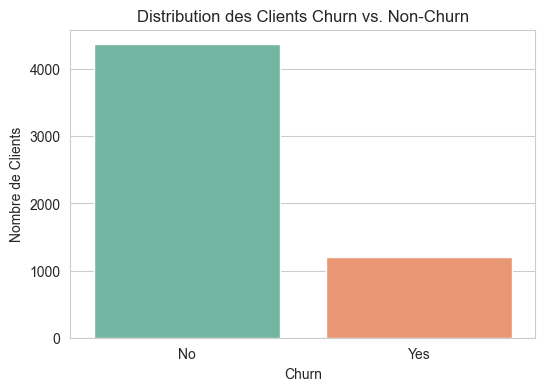


⚠️ ALERTE : Le jeu de données est déséquilibré (Moins de 30% de Churn).
Des techniques spécifiques seront nécessaires pour le Machine Learning (e.g., Oversampling/Undersampling, pondération des classes).


In [ ]:
# --- 5. ANALYSE DE LA VARIABLE CIBLE (CHURN) ---

# Convertir Churn en type catégorie et compter les occurrences
df_final['Churn'] = df_final['Churn'].astype('category')
churn_counts = df_final['Churn'].value_counts()
churn_percentage = df_final['Churn'].value_counts(normalize=True) * 100

print("\n--- Distribution de la Variable Cible ('Churn') ---")
print("Compte:")
print(churn_counts)
print("\nPourcentage:")
print(churn_percentage.round(2).astype(str) + ' %')

# Affichage visuel (à intégrer dans Streamlit)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_final, palette='Set2')
plt.title('Distribution des Clients Churn vs. Non-Churn')
plt.ylabel("Nombre de Clients")
plt.show() 

# Interprétation
if churn_percentage.loc['Yes'] < 30:
    print("\n ALERTE : Le jeu de données est déséquilibré (Moins de 30% de Churn).")
    print("Des techniques spécifiques seront nécessaires pour le Machine Learning (e.g., Oversampling/Undersampling, pondération des classes).")

## Nettoyage des données

In [38]:
# Assumons que df_final est déjà chargé et fusionné, et TotalCharges est converti.
# Si non, inclure les étapes de chargement et fusion précédentes ici.

# --- 1. IMMPUTATION DES VALEURS MANQUANTES ---

# Colonnes Numériques à imputer par la MÉDIANE
# (Identification basée sur l'exploration initiale des fichiers)
numerical_cols_to_impute = [
    'TotalCharges',     # Converti en float, les NaNs sont les clients tenure=0
    'Age',              # Manquants dans clients.csv
    'NbContacts',       # Manquants dans interactions.csv
    'AvgDataUsage_GB',  # Manquants dans usage.csv
    'SatisfactionScore' # Manquants/variables ordinales dans interactions.csv
]

# Colonnes Catégorielles à imputer par le MODE
# (Identification basée sur l'exploration initiale des fichiers)
categorical_cols_to_impute = [
    'Partner',          # Manquants dans clients.csv
    'Dependents',       # Manquants dans clients.csv
    'InternetService',  # Manquants dans contracts.csv
    'TVPackage',        # Manquants dans usage.csv
    'TechSupport'       # Manquants dans usage.csv
]

# Imputation pour les colonnes numériques (Médiane)
for col in numerical_cols_to_impute:
    median_val = df_final[col].median()
    df_final[col].fillna(median_val, inplace=True)
    print(f"Imputation de '{col}' par la Médiane : {median_val:.2f}")

# Imputation pour les colonnes catégorielles (Mode)
for col in categorical_cols_to_impute:
    mode_val = df_final[col].mode()[0] # [0] car .mode() retourne une série
    df_final[col].fillna(mode_val, inplace=True)
    print(f"Imputation de '{col}' par le Mode : '{mode_val}'")

# Vérification finale des NaN (doit être 0 pour ces colonnes)
print("\n--- Vérification après Imputation ---")
print(df_final[numerical_cols_to_impute + categorical_cols_to_impute].isnull().sum())

Imputation de 'TotalCharges' par la Médiane : 2080.04
Imputation de 'Age' par la Médiane : 54.00
Imputation de 'NbContacts' par la Médiane : 2.00
Imputation de 'AvgDataUsage_GB' par la Médiane : 34.40
Imputation de 'SatisfactionScore' par la Médiane : 3.00
Imputation de 'Partner' par le Mode : 'No'
Imputation de 'Dependents' par le Mode : 'No'
Imputation de 'InternetService' par le Mode : 'Fiber optic'
Imputation de 'TVPackage' par le Mode : 'No'
Imputation de 'TechSupport' par le Mode : 'No'

--- Vérification après Imputation ---
TotalCharges         0
Age                  0
NbContacts           0
AvgDataUsage_GB      0
SatisfactionScore    0
Partner              0
Dependents           0
InternetService      0
TVPackage            0
TechSupport          0
dtype: int64


## Encodage des variables categorielles

### Encodage binaire

In [39]:
# --- 2. ENCODAGE DES VARIABLES ---

# A. Encodage de la Variable Cible (TARGET) et des Variables BINAIRES
# La variable cible 'Churn' doit être encodée en 0 et 1.
# Les autres variables binaires ('Yes'/'No') sont traitées de la même manière.

# Variables binaires à convertir en 0/1
binary_cols = [
    'Partner', 
    'Dependents', 
    'TVPackage', 
    'TechSupport', 
    'Churn' # Cible
]

# Encodage de 'gender' (Male/Female)
df_final['gender'] = df_final['gender'].replace({'Male': 1, 'Female': 0})
print("Encodage de 'gender' (Male=1, Female=0) effectué.")

# Encodage des autres variables binaires (Yes/No)
for col in binary_cols:
    # On gère 'No' -> 0, 'Yes' -> 1
    df_final[col] = df_final[col].replace({'Yes': 1, 'No': 0})

print("Encodage des variables binaires (Yes/No) effectué (Yes=1, No=0).")

Encodage de 'gender' (Male=1, Female=0) effectué.
Encodage des variables binaires (Yes/No) effectué (Yes=1, No=0).


### Encodage multi_classes

In [40]:
# B. One-Hot Encoding pour les variables Multi-Classes

# Identification des colonnes restantes de type 'object'
# On exclut 'customerID' (ID), 'FeedbackText' (NLP) et 'gender' (déjà encodé)
multi_class_cols = df_final.select_dtypes(include='object').columns.tolist()
# Suppression de l'ID et de la colonne texte
cols_to_drop_after_ohe = ['customerID', 'FeedbackText']
multi_class_cols = [col for col in multi_class_cols if col not in cols_to_drop_after_ohe]

# Application du One-Hot Encoding
df_final = pd.get_dummies(df_final, columns=multi_class_cols, drop_first=True)

print(f"\nEncodage One-Hot terminé. Le DataFrame a maintenant {df_final.shape[1]} colonnes (Features).")
print(f"Colonnes One-Hot encodées : {multi_class_cols}")

# C. Suppression des colonnes non nécessaires pour le modèle
df_final.drop(columns=cols_to_drop_after_ohe, inplace=True)
print(f"Colonnes 'customerID' et 'FeedbackText' supprimées.")

# Aperçu final
print("\n--- Aperçu du DataFrame Final Prêt pour le ML ---")
print(df_final.head())
print(f"Forme finale du DataFrame: {df_final.shape}")


Encodage One-Hot terminé. Le DataFrame a maintenant 27 colonnes (Features).
Colonnes One-Hot encodées : ['Region', 'ContractType', 'PaymentMethod', 'InternetService']
Colonnes 'customerID' et 'FeedbackText' supprimées.

--- Aperçu du DataFrame Final Prêt pour le ML ---
   gender  SeniorCitizen  Partner  Dependents  tenure   Age Churn  \
0       1              1        1           1       9  41.0     1   
1       0              0        0           0      19  64.0     0   
2       1              0        1           0      12  23.0     0   
3       1              0        1           0      27  44.0     0   
4       1              0        0           0      58  27.0     0   

   MonthlyCharges  TotalCharges  AvgDataUsage_GB  ...  SatisfactionScore  \
0          102.33       3060.07             14.9  ...                1.0   
1           69.48        820.59             34.4  ...                4.0   
2           37.17       2928.24             24.4  ...                1.0   
3         

## Visualisation et analyse

--- Analyse de l'ancienneté (tenure) vs. Churn ---


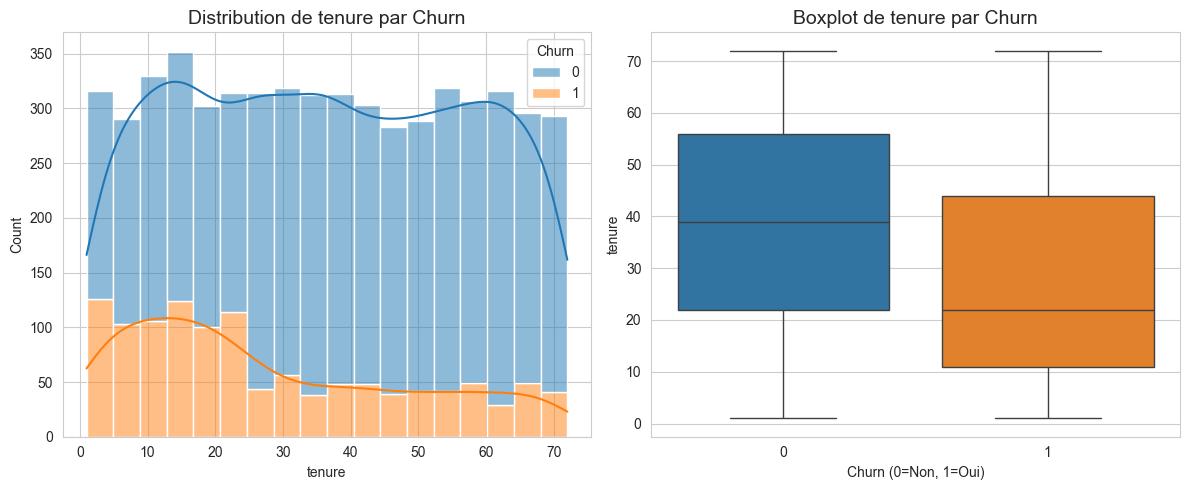


--- Analyse des frais mensuels (MonthlyCharges) vs. Churn ---


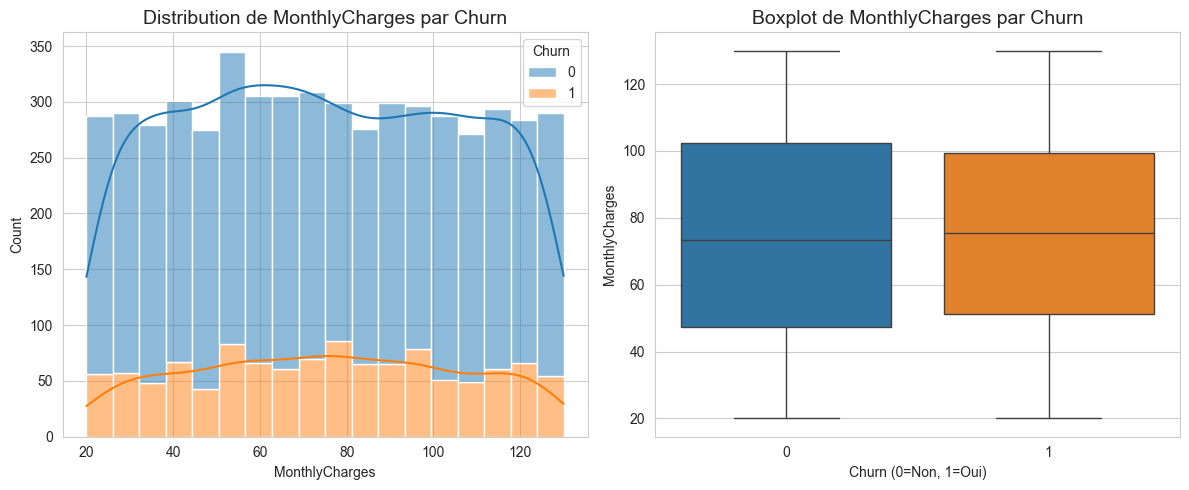


--- Analyse des frais totaux (TotalCharges) vs. Churn ---


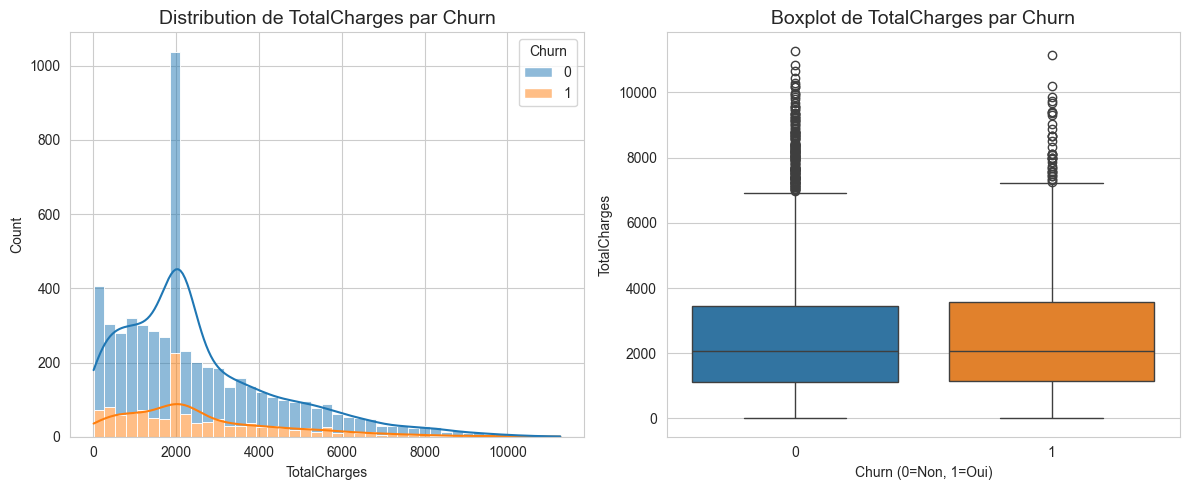


--- Analyse du Type de Contrat (ContractType) vs. Churn ---


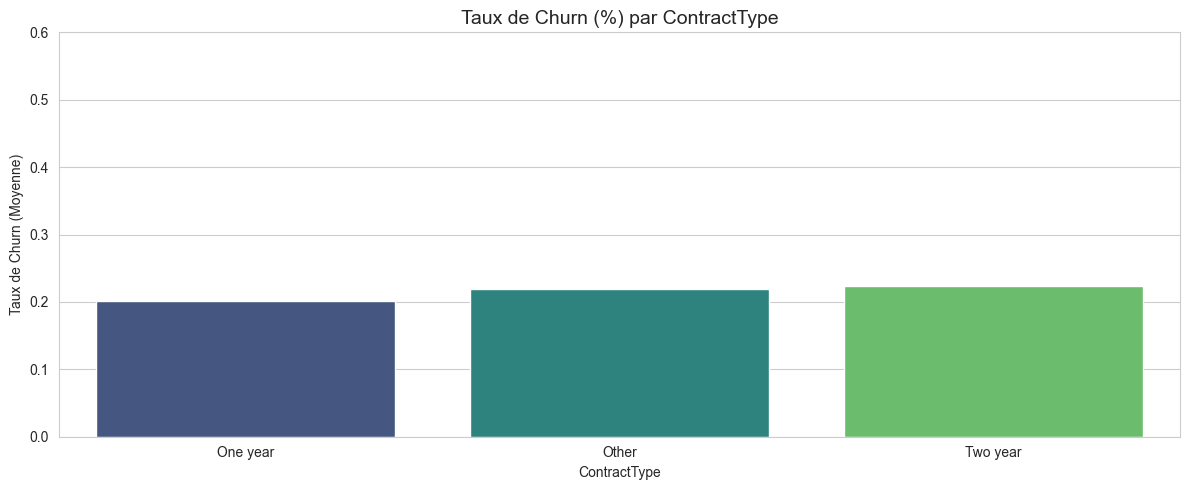


--- Analyse du Service Internet (InternetService) vs. Churn ---


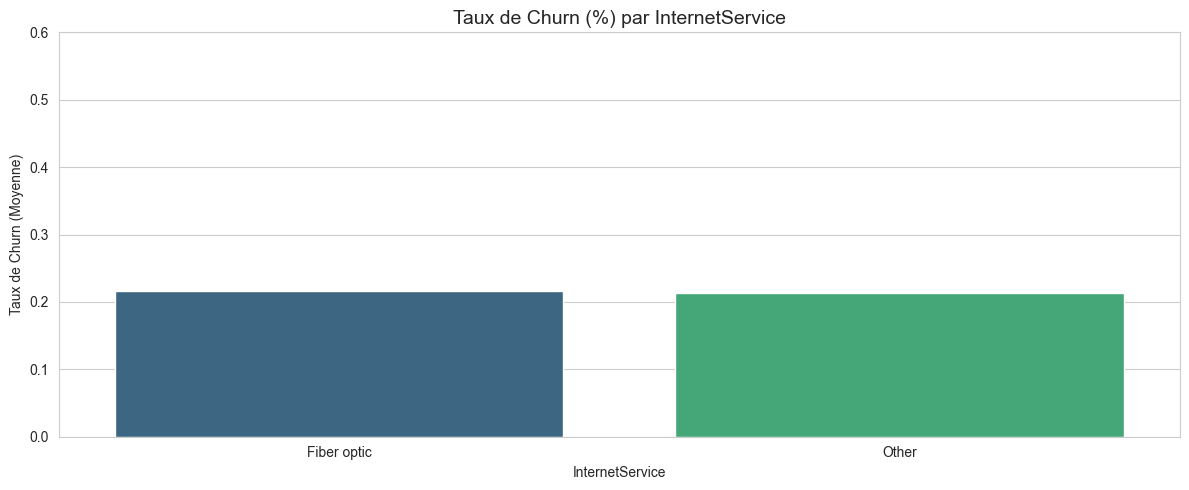


--- Analyse de la méthode de Paiement (PaymentMethod) vs. Churn ---


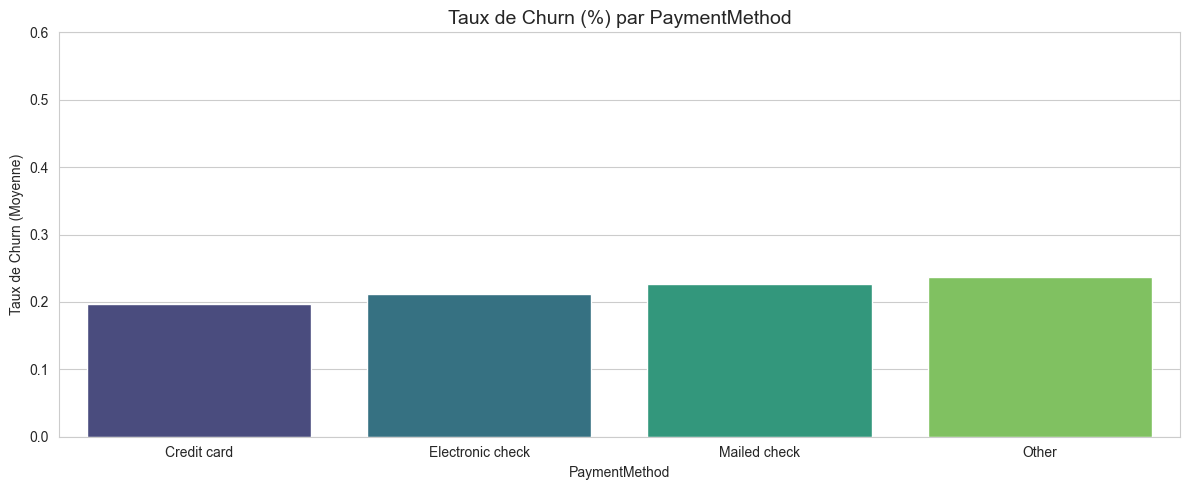


--- Matrice de Corrélation entre les variables numériques et le Churn ---


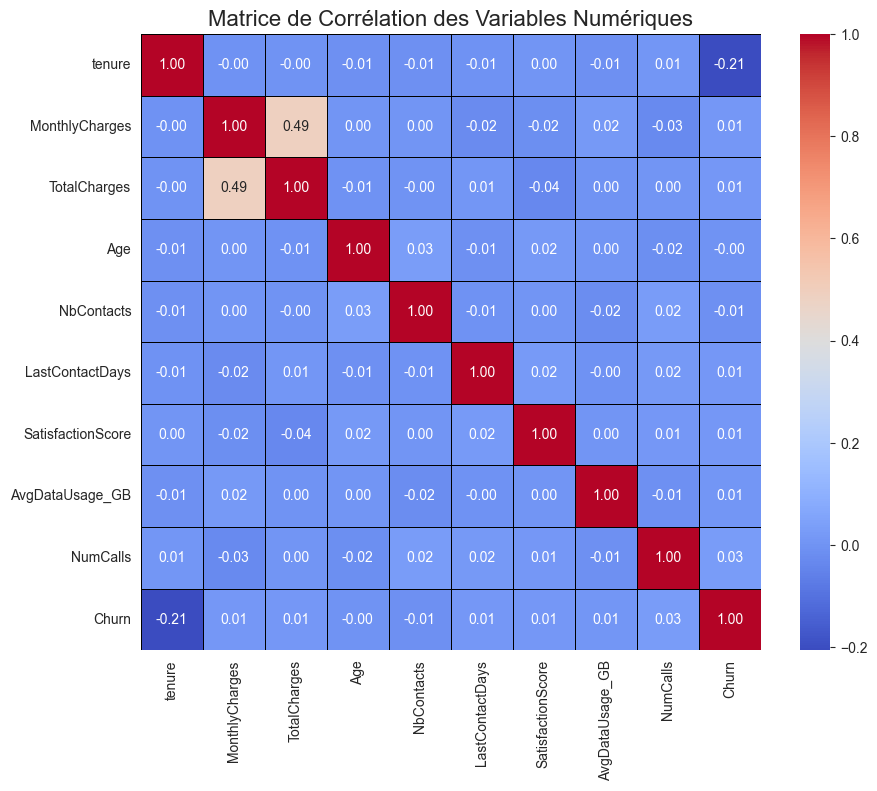

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration de style pour les visualisations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- 1. FONCTIONS UTILES ---

def plot_numerical_feature_vs_churn(df, column):
    """Affiche un histogramme et un boxplot pour une variable numérique en fonction du Churn."""
    plt.figure(figsize=(12, 5))

    # Histogramme (Distribution)
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=column, hue='Churn', kde=True, multiple="stack", palette="tab10")
    plt.title(f'Distribution de {column} par Churn', fontsize=14)
    plt.xlabel(column)
    
    # Boxplot (Relation avec la cible)
    plt.subplot(1, 2, 2)
    sns.boxplot(x='Churn', y=column, data=df, palette="tab10")
    plt.title(f'Boxplot de {column} par Churn', fontsize=14)
    plt.xlabel('Churn (0=Non, 1=Oui)')

    plt.tight_layout()
    plt.show()


def plot_categorical_feature_vs_churn(df, column):
    """
    Affiche la distribution d'une variable catégorielle et son taux de Churn.
    Cette fonction gère deux cas :
    - la colonne originale existe encore dans df (avant One-Hot)
    - la colonne a été one-hot encodée : on recherche les colonnes préfixées par 'column_'
      et on reconstruit les catégories (les lignes où aucune dummy n'est True sont étiquetées 'Other').
    """
    plt.figure(figsize=(12, 5))

    # S'assurer que Churn est numérique pour le calcul de la moyenne
    churn_series = pd.to_numeric(df['Churn'], errors='coerce')

    if column in df.columns:
        churn_rate = df.groupby(column)[churn_series.name].mean().reset_index()
        churn_rate.columns = [column, 'Churn']
    else:
        # Rechercher les colonnes dummies créées par get_dummies (préfixe `column_`)
        dummy_prefix = column + '_'
        dummy_cols = [c for c in df.columns if c.startswith(dummy_prefix)]
        if not dummy_cols:
            # Aucun dummy trouvé : informer clairement et sortir proprement
            raise KeyError(f"Column '{column}' not found in DataFrame and no one-hot columns with prefix '{dummy_prefix}' were detected.")
        
        # Reconstruire une colonne catégorielle à partir des dummies
        labels = pd.Series(['Other'] * len(df), index=df.index)
        for d in dummy_cols:
            suffix = d[len(dummy_prefix):]
            # Les dummies peuvent être bool ou int; on force en bool pour l'indexation
            labels.loc[df[d].astype(bool)] = suffix

        tmp = pd.concat([labels.rename(column), churn_series.rename('Churn')], axis=1)
        churn_rate = tmp.groupby(column)['Churn'].mean().reset_index()

    # Barplot
    sns.barplot(x=column, y='Churn', data=churn_rate, palette="viridis")
    plt.title(f'Taux de Churn (%) par {column}', fontsize=14)
    plt.xlabel(column)
    plt.ylabel('Taux de Churn (Moyenne)')
    plt.ylim(0, 0.6) # Limite fixe pour comparaison facile

    plt.tight_layout()
    plt.show()

# --- 2. ANALYSE DES VARIABLES NUMÉRIQUES CLÉS ---

print("--- Analyse de l'ancienneté (tenure) vs. Churn ---")
plot_numerical_feature_vs_churn(df_final, 'tenure')

print("\n--- Analyse des frais mensuels (MonthlyCharges) vs. Churn ---")
plot_numerical_feature_vs_churn(df_final, 'MonthlyCharges')

print("\n--- Analyse des frais totaux (TotalCharges) vs. Churn ---")
plot_numerical_feature_vs_churn(df_final, 'TotalCharges')


# --- 3. ANALYSE DES VARIABLES CATÉGORIELLES CLÉS ---

print("\n--- Analyse du Type de Contrat (ContractType) vs. Churn ---")
plot_categorical_feature_vs_churn(df_final, 'ContractType')

print("\n--- Analyse du Service Internet (InternetService) vs. Churn ---")
plot_categorical_feature_vs_churn(df_final, 'InternetService')

print("\n--- Analyse de la méthode de Paiement (PaymentMethod) vs. Churn ---")
plot_categorical_feature_vs_churn(df_final, 'PaymentMethod')


# --- 4. MATRICE DE CORRÉLATION ---

print("\n--- Matrice de Corrélation entre les variables numériques et le Churn ---")

# Sélection des colonnes numériques (incluant Churn qui est 0/1)
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Age', 'NbContacts', 
                  'LastContactDays', 'SatisfactionScore', 'AvgDataUsage_GB', 'NumCalls', 'Churn']

# Calcul de la matrice de corrélation
corr_matrix = df_final[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            cbar=True, linewidths=.5, linecolor='black')
plt.title('Matrice de Corrélation des Variables Numériques', fontsize=16)
plt.show()

On supprime la variable totalcharges car la monthlycharges semble plus explicative et indepenente 

                  tenure  MonthlyCharges  TotalCharges     Churn
tenure          1.000000       -0.003641     -0.000396 -0.206040
MonthlyCharges -0.003641        1.000000      0.488412  0.010768
TotalCharges   -0.000396        0.488412      1.000000  0.012473
Churn          -0.206040        0.010768      0.012473  1.000000


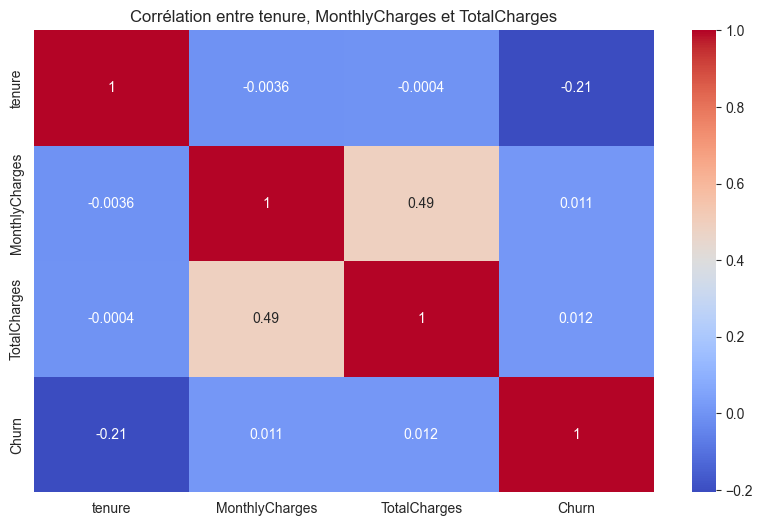


 Corrélation acceptable, conservation de toutes les variables.

Colonnes restantes :
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Age',
       'Churn', 'MonthlyCharges', 'TotalCharges', 'AvgDataUsage_GB',
       'NumCalls', 'TVPackage', 'TechSupport', 'NbContacts', 'LastContactDays',
       'SatisfactionScore', 'Region_North', 'Region_South', 'Region_West',
       'ContractType_One year', 'ContractType_Two year',
       'PaymentMethod_Credit card', 'PaymentMethod_Electronic check',
       'PaymentMethod_Mailed check', 'InternetService_Fiber optic'],
      dtype='object')


In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Vérifions la corrélation entre les variables clés ---
corr = df_final[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
print(corr)

# Visualisation de la corrélation
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Corrélation entre tenure, MonthlyCharges et TotalCharges")
plt.show()

# --- Si corrélation trop forte (> 0.9) entre MonthlyCharges et TotalCharges ---
if abs(corr.loc['MonthlyCharges', 'TotalCharges']) > 0.9:
    print("\n Corrélation très forte détectée entre MonthlyCharges et TotalCharges.")
    print("Suppression de 'TotalCharges' pour éviter la multicolinéarité.")
    df_final.drop(columns=['TotalCharges'], inplace=True)
else:
    print("\n Corrélation acceptable, conservation de toutes les variables.")

# Vérification du nouveau jeu de données
print("\nColonnes restantes :")
print(df_final.columns)


In [ ]:
# CODE POUR IDENTIFIER LES NA RESTANTS
print("\n--- Vérification finale des valeurs manquantes ---")
# On trie pour voir les colonnes avec des NaN en haut
nan_check = df_final.isnull().sum().sort_values(ascending=False)
nan_check = nan_check[nan_check > 0]

if nan_check.empty:
    print(" Aucune valeur NaN restante. Le problème est ailleurs ou vous avez déjà corrigé.")
else:
    print(f" {len(nan_check)} colonne(s) avec des NaN persistants :")
    print(nan_check)


--- Vérification finale des valeurs manquantes ---
❌ 3 colonne(s) avec des NaN persistants :
LastContactDays    627
NumCalls           417
MonthlyCharges     276
dtype: int64


In [45]:
# Colonnes à imputer
cols_to_impute = ['LastContactDays', 'NumCalls', 'MonthlyCharges']

for col in cols_to_impute:
    median_val = df_final[col].median()
    df_final[col].fillna(median_val, inplace=True)
    print(f" '{col}' imputation par médiane : {median_val}")
    
# Vérification
print("\nNombre de NaN après imputation :")
print(df_final[cols_to_impute].isnull().sum())


 'LastContactDays' imputation par médiane : 88.0
 'NumCalls' imputation par médiane : 40.0
 'MonthlyCharges' imputation par médiane : 73.88

Nombre de NaN après imputation :
LastContactDays    0
NumCalls           0
MonthlyCharges     0
dtype: int64


## Phase  ML

Répartition des classes :
Churn
0    0.785
1    0.215
Name: proportion, dtype: float64

===  Logistic Regression (balanced) ===
              precision    recall  f1-score   support

           0       0.86      0.60      0.71       874
           1       0.30      0.64      0.41       240

    accuracy                           0.61      1114
   macro avg       0.58      0.62      0.56      1114
weighted avg       0.74      0.61      0.64      1114

AUC : 0.664

===  Random Forest (balanced) ===
              precision    recall  f1-score   support

           0       0.79      1.00      0.88       874
           1       0.70      0.03      0.06       240

    accuracy                           0.79      1114
   macro avg       0.74      0.51      0.47      1114
weighted avg       0.77      0.79      0.70      1114

AUC : 0.672

 Tableau comparatif des performances :


,Modèle,Accuracy,Recall,Precision,F1,AUC
0,Logistic Regression (balanced),0.608,0.638,0.304,0.412,0.664
1,Random Forest (balanced),0.788,0.029,0.700,0.056,0.672


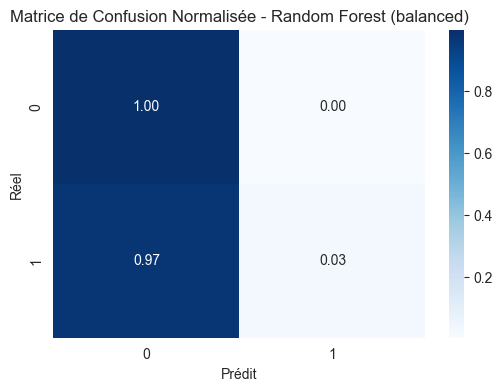

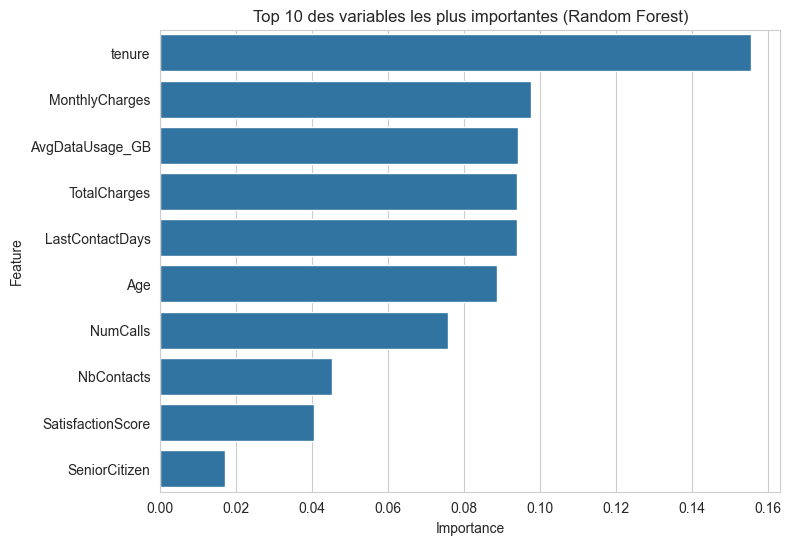


Top 10 variables importantes :
              Feature  Importance
4              tenure    0.155428
6      MonthlyCharges    0.097457
8     AvgDataUsage_GB    0.094203
7        TotalCharges    0.093988
13    LastContactDays    0.093987
5                 Age    0.088641
9            NumCalls    0.075688
12         NbContacts    0.045229
14  SatisfactionScore    0.040356
1       SeniorCitizen    0.017093


In [46]:
# ============================
#  PHASE ML : Préparation + Modélisation
# ============================
# ===============================
#  Modélisation Churn équilibrée
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

# ===============================
# 1 Séparation des données
# ===============================

X = df_final.drop(columns=['Churn'])
y = df_final['Churn']

# Vérif du déséquilibre
print("Répartition des classes :")
print(y.value_counts(normalize=True).round(3))

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# 2 Normalisation des variables numériques
# ===============================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# ===============================
# 3 Entraînement des modèles équilibrés
# ===============================

# Régression Logistique
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# ===============================
# 4 Prédictions et métriques
# ===============================
models = {
    "Logistic Regression (balanced)": log_reg,
    "Random Forest (balanced)": rf
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append([name, acc, rec, prec, f1, auc])

    print(f"\n===  {name} ===")
    print(classification_report(y_test, y_pred))
    print("AUC :", round(auc, 3))

# ===============================
# 5 Comparaison des modèles
# ===============================
results_df = pd.DataFrame(results, columns=['Modèle', 'Accuracy', 'Recall', 'Precision', 'F1', 'AUC'])
print("\n Tableau comparatif des performances :")
display(results_df.round(3))

# ===============================
# 6 Matrice de confusion normalisée
# ===============================
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, rf.predict(X_test), normalize='true'),
            annot=True, cmap='Blues', fmt='.2f')
plt.title('Matrice de Confusion Normalisée - Random Forest (balanced)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# ===============================
# 7 Importance des variables
# ===============================
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 des variables les plus importantes (Random Forest)")
plt.show()

print("\nTop 10 variables importantes :")
print(feature_importance.head(10))


In [47]:
y.value_counts(normalize=True)

Churn
0    0.784842
1    0.215158
Name: proportion, dtype: float64

#### on voit que les classes sont fortement desiquilibrés on peut essayer de jouer sur le parametres du poids de la classe class_weight pour avoir un modele mieux equilibré 

In [48]:
# Ajustement du seuil
y_proba_rf = rf.predict_proba(X_test)[:, 1]
threshold = 0.3  # tu peux tester 0.25, 0.35, etc.

y_pred_rf_adj = (y_proba_rf >= threshold).astype(int)

print("=== Random Forest ajusté (threshold=0.3) ===")
print(classification_report(y_test, y_pred_rf_adj))
print("AUC :", roc_auc_score(y_test, y_proba_rf))


=== Random Forest ajusté (threshold=0.3) ===
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       874
           1       0.36      0.39      0.37       240

    accuracy                           0.72      1114
   macro avg       0.60      0.60      0.60      1114
weighted avg       0.73      0.72      0.72      1114

AUC : 0.6724971395881008


precision ≈ recall → F1-score équilibré (0.36)
AUC stable : le modèle distingue globalement bien les classes.
Accuracy légèrement diminuée : normal, car plus de churners sont détectés (plus de faux positifs).